# Interact with your IMS data

This notebook demonstrates how to interact with various IMS data formats, extract mass spectra, ion images and more.

## Dependencies

```bash
pip install "imzy[hdf5,plot]"
```

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# get basic peak picker from scipy
from scipy.signal import find_peaks

# this will handle the supported file formats
from imzy import get_reader

In [ ]:
path = Path(r"PATH-TO-YOUR-DATA-FILE")
reader = get_reader(path)
reader

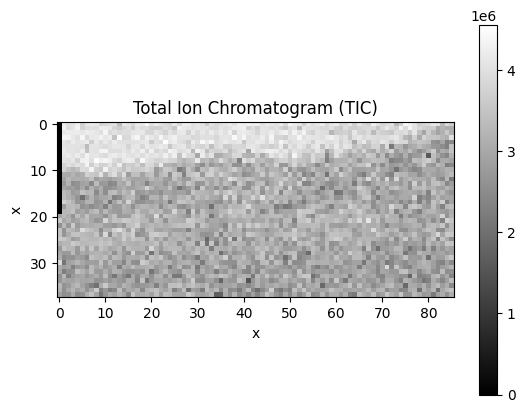

In [4]:
# get TIC array - TIC is returned as a 1D array
tic = reader.get_tic()
# convert the 1d array to 2d for visualization
tic2d = reader.reshape(tic)

fig, ax = plt.subplots()
im = ax.imshow(tic2d, cmap="gray")
ax.set(title="Total Ion Chromatogram (TIC)", xlabel="x", ylabel="x")
plt.colorbar(im)

Summing spectra...: 100%|██████████| 3248/3248 [00:12<00:00, 252.31it/s]


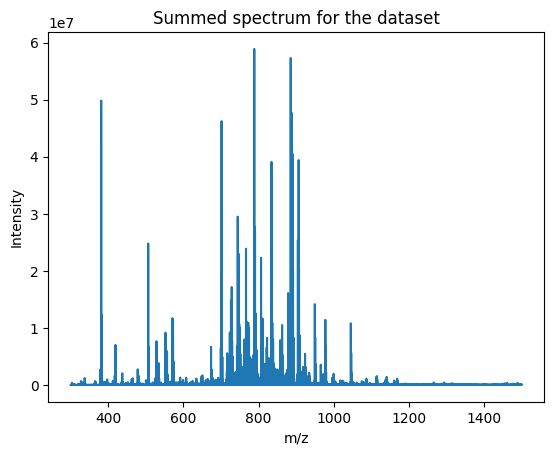

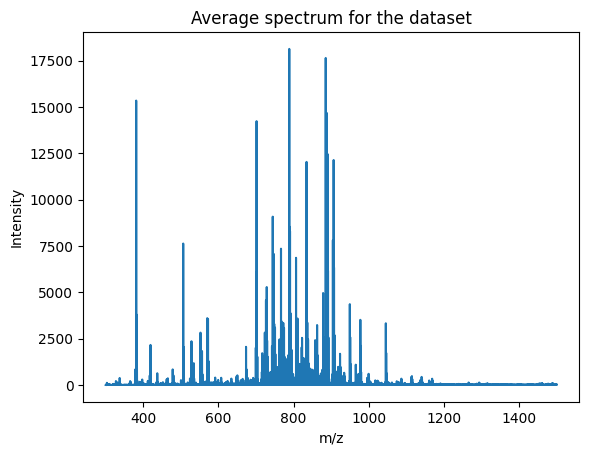

In [5]:
# get the summed spectrum for the entire dataset
x, y = reader.get_summed_spectrum(reader.pixels)
fig, ax = plt.subplots()
ax.plot(x, y)
ax.set(xlabel="m/z", ylabel="Intensity", title="Summed spectrum for the dataset")

# convert summed spectrum to an average spectrum
y_avg = y / reader.n_pixels
fig, ax = plt.subplots()
ax.plot(x, y_avg)
_ = ax.set(xlabel="m/z", ylabel="Intensity", title="Average spectrum for the dataset")

In [6]:
# you can also obtain normalizations for each pixel
# the data is returned as dict mapping of 'normalization name' to array of scaling factors
# the values are to be used as multipliers of the spectra
norms = reader.get_normalizations()
# get the names of the available normalizations
list(norms.keys())

Computing normalizations...: 100%|██████████| 3248/3248 [00:33<00:00, 98.08it/s] 


['TIC',
 'RMS',
 'Median',
 '0-95% TIC',
 '0-90% TIC',
 '5-100% TIC',
 '10-100% TIC',
 '5-95% TIC',
 '10-90% TIC',
 '0-norm',
 '2-norm',
 '3-norm']

[Text(0.5, 1.0, 'TIC normalization factors'),
 Text(0.5, 0, 'x'),
 Text(0, 0.5, 'y')]

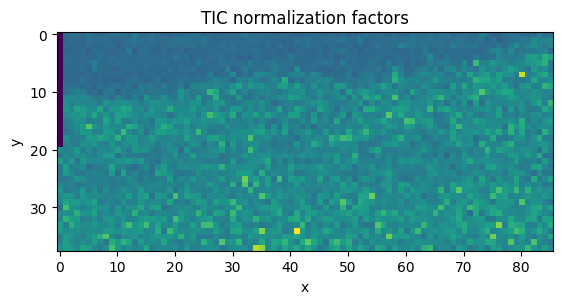

In [7]:
# you can also visualise the normalization factors
scales2d = reader.reshape(norms["TIC"])
fig, ax = plt.subplots()
im = ax.imshow(scales2d, cmap="viridis")
ax.set(title="TIC normalization factors", xlabel="x", ylabel="y")

Summing spectra...: 100%|██████████| 3248/3248 [00:08<00:00, 393.04it/s]


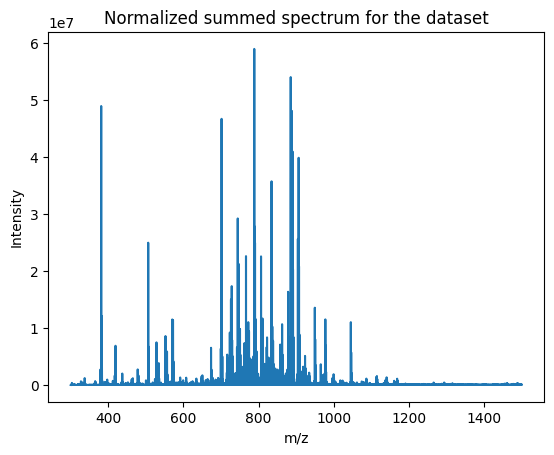

In [8]:
# you can use the normalization values when extracting the summed spectrum
scales = norms["TIC"]
x, y_norm = reader.get_summed_spectrum(reader.pixels, scales=scales)
fig, ax = plt.subplots()
ax.plot(x, y_norm)
_ = ax.set(xlabel="m/z", ylabel="Intensity", title="Normalized summed spectrum for the dataset")

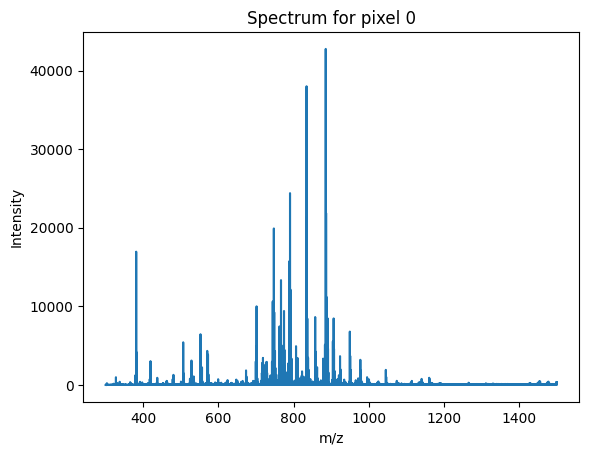

In [9]:
# get random spectrum from the dataset
x, y = reader.get_spectrum(0)

fig, ax = plt.subplots()
ax.plot(x, y)
_ = ax.set(xlabel="m/z", ylabel="Intensity", title="Spectrum for pixel 0")

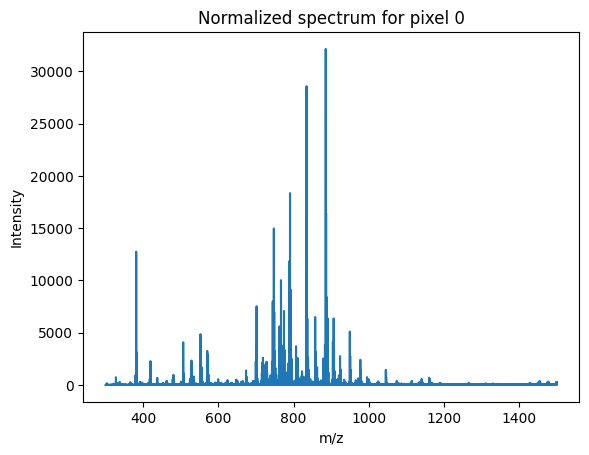

In [10]:
# get random spectrum from the dataset
x, y = reader.get_spectrum(0)
y = y * scales[0]

fig, ax = plt.subplots()
ax.plot(x, y)
_ = ax.set(xlabel="m/z", ylabel="Intensity", title="Normalized spectrum for pixel 0")

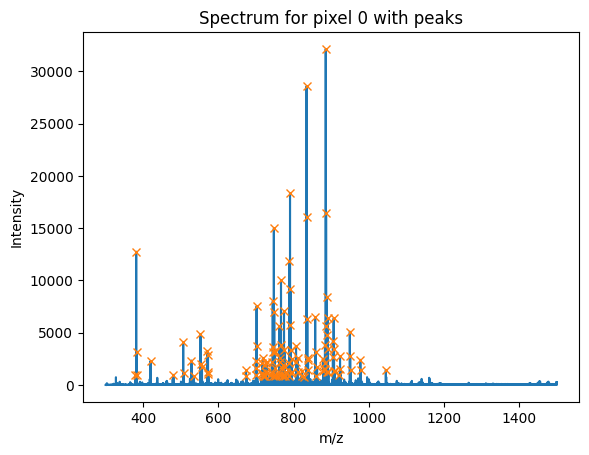

In [11]:
# find peaks in the spectrum
indices, _ = find_peaks(y, height=np.mean(y) + 3 * np.std(y), distance=5)
px = x[indices]
py = y[indices]

fig, ax = plt.subplots()
ax.plot(x, y)
ax.plot(px, py, "x")
_ = ax.set(xlabel="m/z", ylabel="Intensity", title="Spectrum for pixel 0 with peaks")

Iterating spectra...: 100%|██████████| 3248/3248 [00:05<00:00, 576.04it/s]


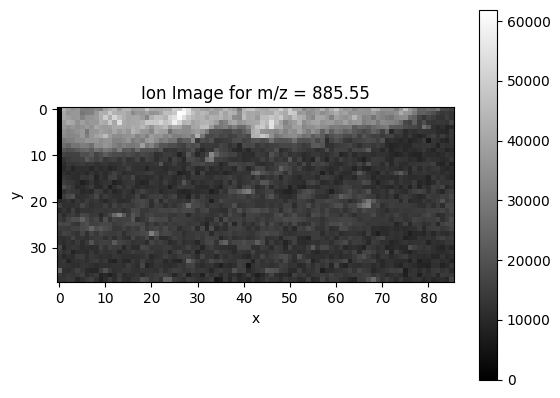

In [12]:
# extract ion image for a given m/z value with a tolerance
# let's get the highest peak in the spectrum
mz = px[np.argmax(py)]

# you can extract images one-by-one which can be fairly slow, or in batches
# here, we just get a single image with integration window of 5ppm but you could also specify in Da
image_for_mz = reader.get_ion_image(mz, ppm=5)

fig, ax = plt.subplots()
im = ax.imshow(image_for_mz, cmap="gray")
ax.set(title=f"Ion Image for m/z = {mz:.2f}", xlabel="x", ylabel="y")
plt.colorbar(im)

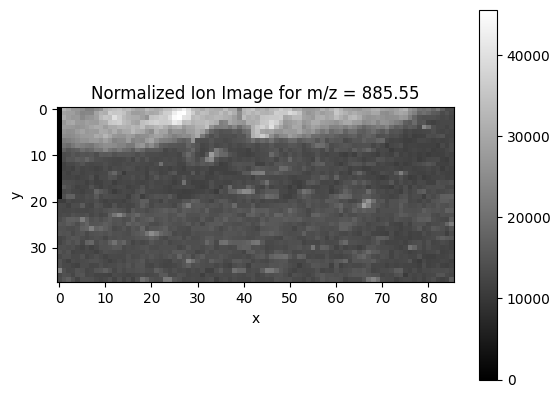

In [13]:
# you can also normalize the image using the normalization factors
# however to do that you need to provide the normalization factors as a 2D array
scales2d = reader.reshape(scales)
image_for_mz_norm = image_for_mz * scales2d
fig, ax = plt.subplots()
im = ax.imshow(image_for_mz_norm, cmap="gray")
ax.set(title=f"Normalized Ion Image for m/z = {mz:.2f}", xlabel="x", ylabel="y")
plt.colorbar(im)

In [14]:
# or you can extract images in batches which is much faster
images_for_mzs = reader.get_ion_images(px, ppm=5)

Iterating spectra...: 100%|██████████| 3248/3248 [00:07<00:00, 446.37it/s]


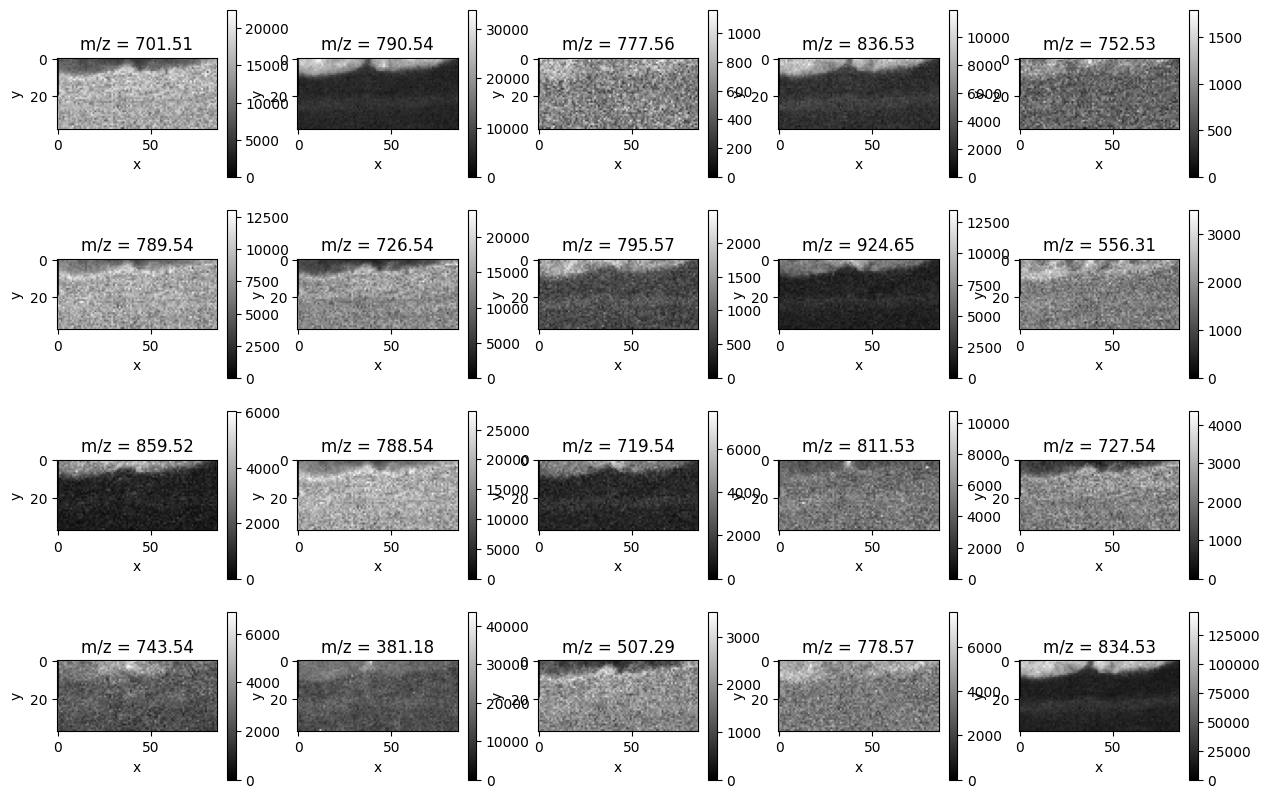

In [15]:
# let's plot a couple of images, maybe random 20 in a grid of 4x5
n_images = 20
random_indices = np.random.choice(len(px), size=n_images, replace=False)
fig, axs = plt.subplots(4, 5, figsize=(15, 10))
for i, ax in enumerate(axs.flat):
    if i < n_images:
        im = ax.imshow(images_for_mzs[random_indices[i]], cmap="gray")
        ax.set(title=f"m/z = {px[random_indices[i]]:.2f}", xlabel="x", ylabel="y")
        plt.colorbar(im, ax=ax)
    else:
        ax.axis("off")